# **1. Environment Setup and Data Download**

## 1.0 Environment

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch

SAVE_PATH = '/content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Project folder is ready at: {SAVE_PATH}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Project folder is ready at: /content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models
Using device: cuda


## 1.1 Data Acquisition

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"motazadel","key":"4c7703e3c177d89e5b64ba8d4efe2697"}'}

In [4]:
!pip install kaggle split-folders


!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone

!unzip -q ct-kidney-dataset-normal-cyst-tumor-and-stone.zip -d kidney_dataset

Dataset URL: https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone
License(s): copyright-authors
 94% 1.43G/1.52G [00:21<00:03, 29.9MB/s]
100% 1.52G/1.52G [00:21<00:00, 77.2MB/s]


In [5]:
!splitfolders --ratio 0.8 0.1 0.1 --output processed_dataset --seed 42 kidney_dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone


Copying files: 12446 files [00:08, 1442.57 files/s]


# **2. Preprocessing and Data Preparation**

In [6]:
# Define Transforms and Create DataLoaders

import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

# 1. Define paths and constants
data_dir = 'processed_dataset'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
# Standard ImageNet mean/std for transfer learning
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# 2. Define Training Transforms (with Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 3. Define Validation/Test Transforms (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 4. Create Datasets using ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# 6. Get class names
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Training images: {len(train_dataset)} | Validation images: {len(val_dataset)} | Test images: {len(test_dataset)}")

Class names: ['Cyst', 'Normal', 'Stone', 'Tumor']
Number of classes: 4
Training images: 9955 | Validation images: 1242 | Test images: 1249


In [7]:
# Handling Class Imbalance

from collections import Counter

# Get the counts of each class in the training set
class_counts = Counter(train_dataset.targets)
print(f"\nOriginal class counts: {class_counts}")

# Sort counts by class index (0=Cyst, 1=Normal, 2=Stone, 3=Tumor)
# This order MUST match train_dataset.classes
counts = [class_counts[i] for i in range(num_classes)]
print(f"Counts per class (index order): {counts}")

# Calculate weights (Inverse Frequency Method)
# weight = total_samples / (num_classes * count_for_that_class)
total_samples = len(train_dataset)
class_weights = []
for count in counts:
    # Adding a small epsilon to avoid division by zero if a class had 0 samples
    weight = total_samples / (num_classes * (count + 1e-6))
    class_weights.append(weight)

# Convert weights to a PyTorch tensor and send to GPU
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Calculated Class Weights: {class_weights_tensor}")
print("Weights calculated and sent to device.")



Original class counts: Counter({1: 4061, 0: 2967, 3: 1826, 2: 1101})
Counts per class (index order): [2967, 4061, 1101, 1826]
Calculated Class Weights: tensor([0.8388, 0.6128, 2.2604, 1.3630], device='cuda:0')
Weights calculated and sent to device.


# **3. Modeling (Model Building and Training)**

## 3.0 Training & Validation Functions

In [8]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm # For progress bars

# Function for one training epoch
def train_step(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions.double() / total_samples
    return epoch_loss, epoch_acc.item()

# Function for one validation epoch
def val_step(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Validating"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions.double() / total_samples
    return epoch_loss, epoch_acc.item()

# Main training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, model_save_name):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    model_save_path = os.path.join(SAVE_PATH, model_save_name)

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_step(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = val_step(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        # Save the best model weights (required by assessment)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            print(f"  New best model saved to {model_save_path} with Val Acc: {best_val_acc:.4f}")

        print("-" * 30)

    print(f"Finished Training. Best Val Acc: {best_val_acc:.4f}")
    return history

## 3.1 Baseline CNN Model

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 224 -> 112
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 112 -> 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 56 -> 28
        )
        self.flat = nn.Flatten()
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flat(x)
        x = self.fc_layers(x)
        return x

# --- Run Baseline Training ---
print("--- Starting Baseline CNN Training (Sanity Check) ---")
baseline_model = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

# Train for only 5 epochs
baseline_history = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=5,
    model_save_name="baseline_model.pth"
)
print("--- Baseline Training Finished ---")

--- Starting Baseline CNN Training (Sanity Check) ---
Epoch 1/5


Validating: 100%|██████████| 39/39 [00:07<00:00,  4.96it/s]


  Train Loss: 0.6382 | Train Acc: 0.7557
  Val Loss:   0.1952 | Val Acc:   0.9243
  New best model saved to /content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models/baseline_model.pth with Val Acc: 0.9243
------------------------------
Epoch 2/5


Validating: 100%|██████████| 39/39 [00:06<00:00,  5.61it/s]


  Train Loss: 0.1651 | Train Acc: 0.9425
  Val Loss:   0.0393 | Val Acc:   0.9911
  New best model saved to /content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models/baseline_model.pth with Val Acc: 0.9911
------------------------------
Epoch 3/5


...

  Train Loss: 0.0804 | Train Acc: 0.9741
  Val Loss:   0.0303 | Val Acc:   0.9879
------------------------------
Epoch 4/5


Validating: 100%|██████████| 39/39 [00:08<00:00,  4.45it/s]


  Train Loss: 0.0521 | Train Acc: 0.9827
  Val Loss:   0.0106 | Val Acc:   0.9984
  New best model saved to /content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models/baseline_model.pth with Val Acc: 0.9984
------------------------------
Epoch 5/5


Validating: 100%|██████████| 39/39 [00:08<00:00,  4.49it/s]

  Train Loss: 0.0416 | Train Acc: 0.9858
  Val Loss:   0.0070 | Val Acc:   0.9976
------------------------------
Finished Training. Best Val Acc: 0.9984
--- Baseline Training Finished ---


## 3.2 Transfer Learning Model (ResNet50)

In [10]:
from torchvision import models

# 1. Load pre-trained ResNet50
model_tl = models.resnet50(pretrained=True)

# 2. Freeze all parameters in the base model
for param in model_tl.parameters():
    param.requires_grad = False

# 3. Replace the final layer (the "head")
num_ftrs = model_tl.fc.in_features                  #2048
model_tl.fc = nn.Linear(num_ftrs, num_classes)     #4

# 4. Move model to GPU
model_tl = model_tl.to(device)

# 5. Define criterion and optimizer (only for the new head)
criterion_tl = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_tl = optim.Adam(model_tl.fc.parameters(), lr=0.001) # Only optimize the new fc layer

# --- Run Transfer Learning Training ---
print("--- Starting Transfer Learning Training (Main Model) ---")
NUM_EPOCHS = 30 # Train for longer
tl_history = train_model(
    model=model_tl,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_tl,
    optimizer=optimizer_tl,
    device=device,
    num_epochs=NUM_EPOCHS,
    model_save_name="best_transfer_model.pth"
)
print("--- Transfer Learning Training Finished ---")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


--- Starting Transfer Learning Training (Main Model) ---
Epoch 1/30


Validating: 100%|██████████| 39/39 [00:08<00:00,  4.34it/s]


...

  Train Loss: 0.3171 | Train Acc: 0.8879
  Val Loss:   0.2609 | Val Acc:   0.9002
------------------------------
Epoch 29/30


Validating: 100%|██████████| 39/39 [00:09<00:00,  4.31it/s]


  Train Loss: 0.3052 | Train Acc: 0.8890
  Val Loss:   0.2733 | Val Acc:   0.9147
  New best model saved to /content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models/best_transfer_model.pth with Val Acc: 0.9147
------------------------------
Epoch 30/30


Validating: 100%|██████████| 39/39 [00:09<00:00,  4.22it/s]


  Train Loss: 0.2880 | Train Acc: 0.9010
  Val Loss:   0.2478 | Val Acc:   0.9203
  New best model saved to /content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models/best_transfer_model.pth with Val Acc: 0.9203
------------------------------
Finished Training. Best Val Acc: 0.9203
--- Transfer Learning Training Finished ---


# **4. Evaluation and Visualization**

## 4.0 Plot Training History

Training plots saved to /content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models/transfer_learning_training_plots.png


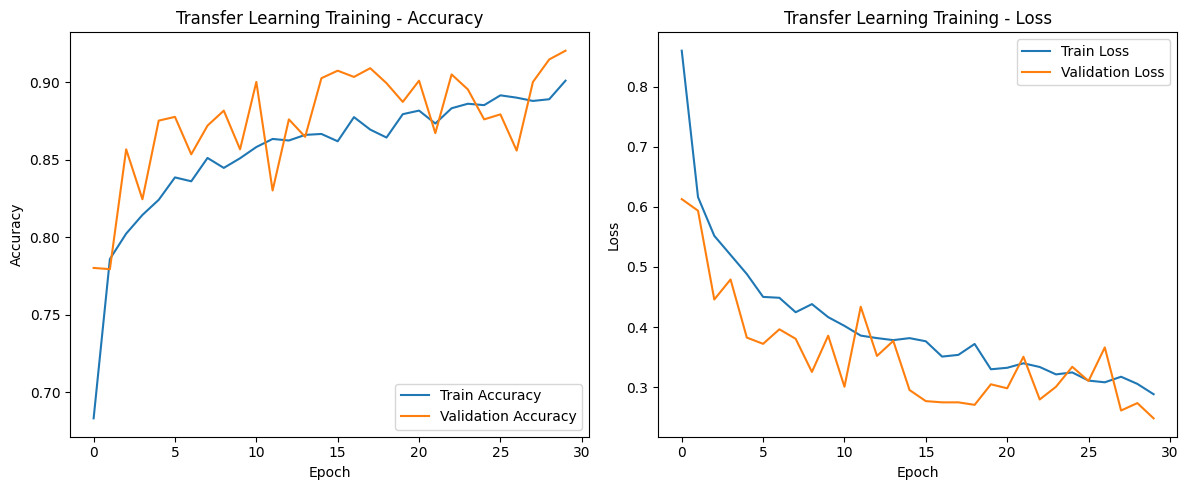

In [11]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    # Save the plot (required by assessment)
    plot_save_path = os.path.join(SAVE_PATH, f"{title.lower().replace(' ', '_')}_plots.png")
    plt.savefig(plot_save_path) # .png
    print(f"Training plots saved to {plot_save_path}")
    plt.show()

# Plot the history for our main model
plot_history(tl_history, "Transfer Learning Training")

## 4.1 Evaluation on Test Set

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Testing: 100%|██████████| 40/40 [00:10<00:00,  3.95it/s]



       FINAL TEST SET EVALUATION
Test Accuracy: 92.47%


Classification Report:
              precision    recall  f1-score   support

        Cyst       0.97      0.91      0.93       372
      Normal       0.97      0.95      0.96       509
       Stone       0.74      0.95      0.83       139
       Tumor       0.91      0.88      0.90       229

    accuracy                           0.92      1249
   macro avg       0.90      0.92      0.91      1249
weighted avg       0.93      0.92      0.93      1249



Confusion Matrix:
Confusion matrix saved to /content/drive/MyDrive/Assessments/Medsoft/Task1-Kidney_Image_Classification/saved_models/confusion_matrix.png


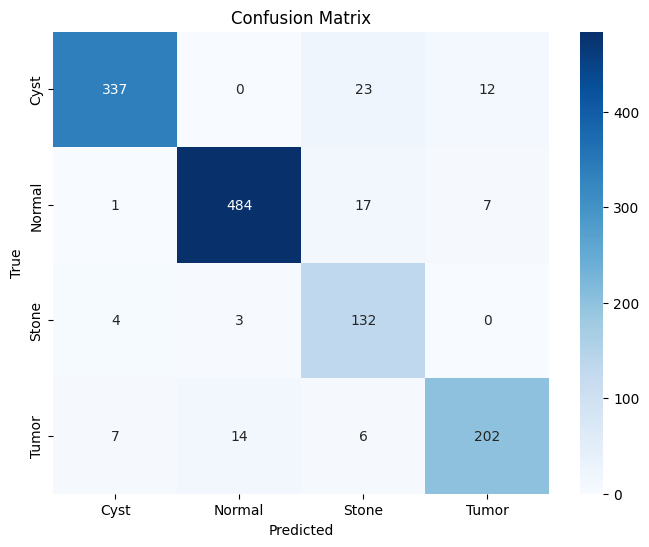

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np

# 1. Load the best model weights we saved during training
model_eval = models.resnet50(pretrained=False) # Start with a blank model
num_ftrs = model_eval.fc.in_features
model_eval.fc = nn.Linear(num_ftrs, num_classes) # Add the correct head
model_eval.load_state_dict(torch.load(os.path.join(SAVE_PATH, "best_transfer_model.pth")))
model_eval = model_eval.to(device)
model_eval.eval()

# 2. Get predictions on the test set
y_pred = []
y_true = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model_eval(inputs)
        _, preds = torch.max(outputs, 1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# 3. Calculate all required metrics
print("\n" + "="*30)
print("       FINAL TEST SET EVALUATION")
print("="*30)

# Metric 1: Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("\n")

# Metrics 2, 3, 4: Precision, Recall, F1-Score
print("Classification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)
print("\n")

# Metric 5: Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# Save the confusion matrix
cm_save_path = os.path.join(SAVE_PATH, "confusion_matrix.png")
plt.savefig(cm_save_path)
print(f"Confusion matrix saved to {cm_save_path}")
plt.show()